In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

from concurrent.futures import ProcessPoolExecutor
from itertools import product

from sklearn.decomposition import NMF
from skimage.metrics import mean_squared_error

## Recommender Systems

We use the dataset from movielens to build a recommender system

In [ ]:
#Reading wine datasets
df_wine = pd.read_csv('winequality-red.csv', sep=';')


#Reading rating prediction dataset (rating scale 1-5). http://grouplens.org/datasets/movielens/100k/

ratings_df = pd.read_csv('datasets/ml-100k/ml-100k/u.data', sep='\t',  header=None, names=['user-id', 'item-id', 'rating', 'timestamp'], encoding='latin-1', engine='python')
movies_df = pd.read_csv('datasets/ml-100k/ml-100k/u.item', sep='|', header=None, names=['item-id', 'title', 'release_date', 'video_release_date', 'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'], encoding='latin-1', engine='python')
users_df = pd.read_csv('datasets/ml-100k/ml-100k/u.user', sep='|', header=None,  names=['user-id', 'age', 'gender', 'occupation', 'zip-code'], encoding='latin-1', engine='python')


#### Statistical Analysis on wine dataset

In [93]:
print(df_wine.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

#### Statistical Analysis on Rating dataset


In [103]:
#First we drop columns that are unnecessary and may not provide any useful information
movies_df.drop(columns=['imdb_url', 'video_release_date'], inplace=True)

#Merge users and movies to rating dataset
rating_df = ratings_df.merge(users_df, on='user-id').merge(movies_df, on='item-id')


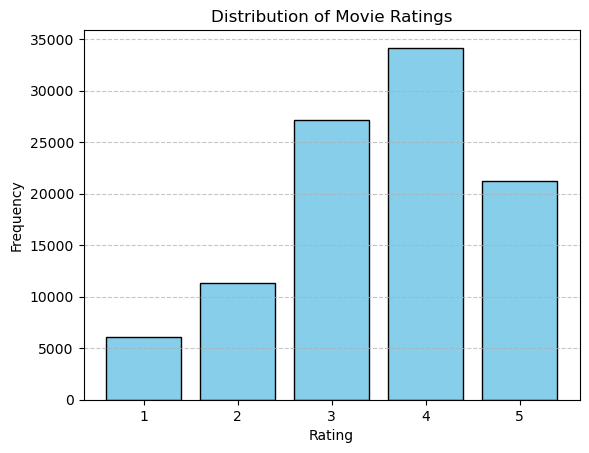

In [104]:
#Plot rating distribution across the entire dataset
rating_counts = rating_df['rating'].value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Movie Ratings')
plt.xticks(rating_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


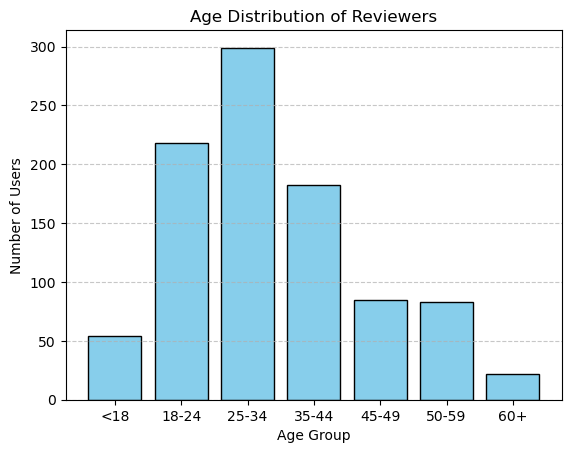

In [105]:
#Find age distribution among users
age_bins = [0, 18, 25, 35, 45, 50, 60, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-49', '50-59', '60+']
# Assign age groups based on user age
rating_df['age_group'] = pd.cut(rating_df['age'], bins=age_bins, labels=age_labels)

# Select unique users with their age groups (one entry per user)
unique_users = rating_df[['user-id', 'age_group']].drop_duplicates()

# Count users per age group
age_group_user_counts = unique_users['age_group'].value_counts().sort_index()

# Plot
plt.bar(age_group_user_counts.index, age_group_user_counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.title('Age Distribution of Reviewers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

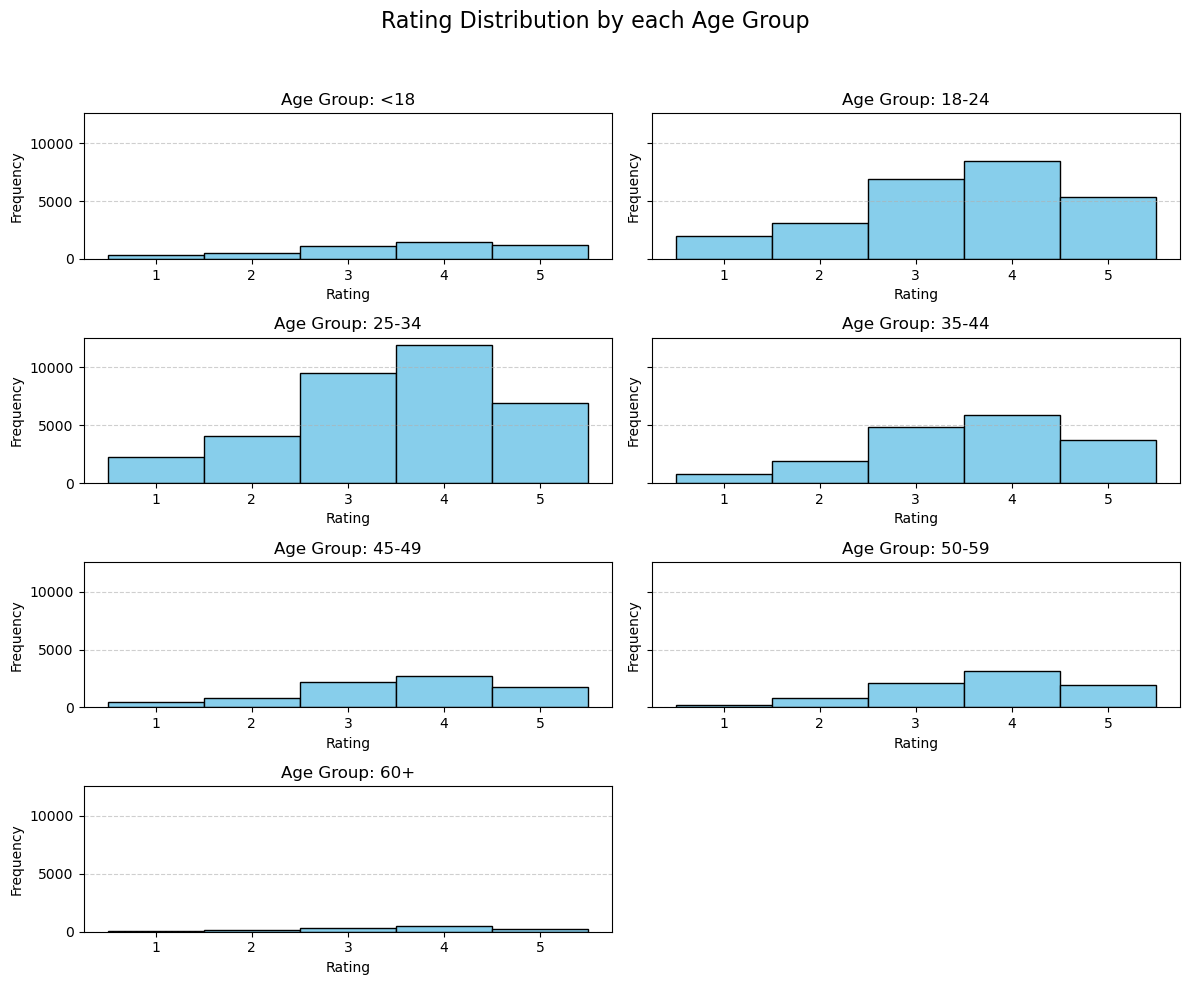

In [106]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 10), sharey=True)
axes = axes.flatten()

# Plot histogram for each age group
for i, group in enumerate(age_labels):
    group_data = rating_df[rating_df['age_group'] == group]['rating']
    axes[i].hist(group_data, bins=range(1, 7), align='left', color='skyblue', edgecolor='black')
    axes[i].set_title(f'Age Group: {group}')
    axes[i].set_xticks(range(1, 6))
    axes[i].set_xlabel('Rating')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Rating Distribution by each Age Group', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [107]:
mean_ratings = rating_df.groupby('age_group')['rating'].mean().sort_index()
mean_ratings_df = mean_ratings.reset_index().rename(columns={'rating': 'Average Rating', 'age_group': 'Age Group'})
display(mean_ratings_df)

/tmp/ipykernel_1836/4016450455.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ratings = rating_df.groupby('age_group')['rating'].mean().sort_index()


TypeError: 'bool' object is not callable

From the means and the rating distribution by age group it can be inferred that the young adults of ages 18 - 24 are the most critical of the movies that they see.

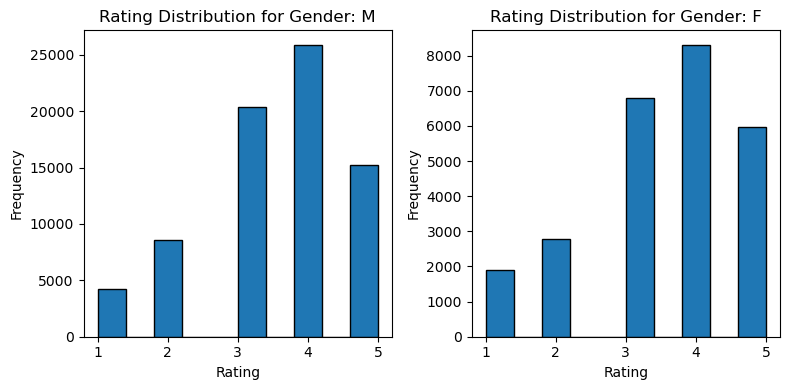

In [9]:
#Plot distribution of ratings by gender
genders = rating_df['gender'].unique()
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True)

for i, gender in enumerate(genders):
    ax = axes[i] if len(genders) > 1 else axes
    gender_ratings = rating_df[rating_df['gender'] == gender]['rating']
    ax.hist(gender_ratings, bins=10, edgecolor='black')
    ax.set_title(f'Rating Distribution for Gender: {gender}')
    ax.set_ylabel('Frequency')
    ax.set_xlabel('Rating')

plt.tight_layout()
plt.show()

Next we find the most reviewed genres by age

In [89]:

genre_cols = ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# Prepare an empty DataFrame to store counts
counts = pd.DataFrame(index=age_labels, columns=genre_cols).fillna(0).infer_objects()

for genre in genre_cols:
    genre_counts = rating_df[rating_df[genre] == 1].groupby('age_group', observed=False).size()
    for idx, val in genre_counts.items():
        counts.loc[idx, genre] = val

counts = counts.astype(int)
display(counts.T)

TypeError: 'bool' object is not callable

In [99]:
# For each age group, get genres ordered by number of ratings (descending)
most_reviewed_genres = {}

for age_group in counts.index:
    # Sort genres by count descending
    sorted_genres = counts.loc[age_group].sort_values(ascending=False)
    most_reviewed_genres[age_group] = sorted_genres[sorted_genres > 0].index.tolist()


# Create a dataframe from the dictionary
df_display = pd.DataFrame.from_dict(most_reviewed_genres, orient='index').transpose()
display(df_display)

TypeError: 'bool' object is not callable

Next we find the highest rated genres for each age group

In [12]:

top_n = 5  # Number of top genres to return per age group

# Dictionary to store top genres with highest average rating per age group
top_rated_genres_by_age = {}

# Iterate through each age group
for age_group in age_labels:
    age_group_df = rating_df[rating_df['age_group'] == age_group]

    # Calculate average rating for each genre
    avg_ratings = {}
    for genre in genre_cols:
        genre_ratings = age_group_df[age_group_df[genre] == 1]['rating']
        if len(genre_ratings) > 0:
            avg_ratings[genre] = genre_ratings.mean()

    # Sort genres by average rating descending
    sorted_genres = sorted(avg_ratings.items(), key=lambda x: x[1], reverse=True)
    top_rated_genres_by_age[age_group] = sorted_genres[:top_n]

# Print results
for age_group, genres in top_rated_genres_by_age.items():
    print(f"Age group {age_group}:")
    for genre, avg_rating in genres:
        print(f"  {genre}: {avg_rating:.2f}")
    print()


Age group <18:
  Mystery: 5.00
  Romance: 4.50
  War: 4.17
  Action: 4.00
  Documentary: 4.00

Age group 18-24:
  Documentary: 5.00
  Film-Noir: 4.00
  Crime: 3.80
  Musical: 3.80
  Animation: 3.67

Age group 25-34:
  Film-Noir: 4.33
  Western: 4.33
  Crime: 3.88
  Musical: 3.83
  Mystery: 3.74

Age group 35-44:
  Western: 4.33
  Musical: 3.89
  Crime: 3.88
  Animation: 3.86
  Sci-Fi: 3.83

Age group 45-49:
  Crime: 4.27
  Mystery: 4.00
  War: 4.00
  Sci-Fi: 3.90
  Children's: 3.88

Age group 50-59:
  Documentary: 4.00
  Western: 4.00
  Adventure: 3.78
  War: 3.78
  Romance: 3.75

Age group 60+:
  War: 4.67
  Crime: 4.00
  Horror: 4.00
  Sci-Fi: 4.00
  Thriller: 3.83



Highest rated genres for each gender

In [13]:
top_n = 5  # Number of top genres to return per age group

# Dictionary to store top genres with highest average rating per age group
top_rated_genres_by_gender = {}

# Iterate through each age group
for gender in genders:
    gender_df = rating_df[rating_df['gender'] == gender]

    # Calculate average rating for each genre
    avg_ratings = {}
    for genre in genre_cols:
        genre_ratings = gender_df[gender_df[genre] == 1]['rating']
        if len(genre_ratings) > 0:
            avg_ratings[genre] = genre_ratings.mean()

    # Sort genres by average rating descending
    sorted_genres = sorted(avg_ratings.items(), key=lambda x: x[1], reverse=True)
    top_rated_genres_by_gender[gender] = sorted_genres[:top_n]

# Print results
for gender, genres in top_rated_genres_by_gender.items():
    print(f"Gender {gender}:")
    for genre, avg_rating in genres:
        print(f"  {genre}: {avg_rating:.2f}")
    print()


Gender M:
  Film-Noir: 3.97
  War: 3.83
  Drama: 3.70
  Documentary: 3.69
  Mystery: 3.66

Gender F:
  War: 3.78
  Film-Noir: 3.74
  Drama: 3.66
  Romance: 3.66
  Musical: 3.64



Next we find the average ratings grouped by occupation of the reviewers

In [14]:
rating_df.groupby('occupation')['rating'].mean().sort_values(ascending=False)


occupation
none             3.779134
lawyer           3.735316
doctor           3.688889
educator         3.670621
artist           3.653380
administrator    3.635646
scientist        3.611273
salesman         3.582944
programmer       3.568260
librarian        3.560781
other            3.552377
engineer         3.541407
technician       3.532230
student          3.515143
marketing        3.485641
retired          3.466750
entertainment    3.441050
writer           3.375723
executive        3.349104
homemaker        3.301003
healthcare       2.896220
Name: rating, dtype: float64

The top rated genres for each occupation

In [15]:
top_n = 5  # Number of top genres to return per occupation


# Dictionary to store results
top_rated_genres_by_occupation = {}

# Get all unique occupations
occupations = rating_df['occupation'].unique()

# Iterate through each occupation
for occupation in occupations:
    occ_df = rating_df[rating_df['occupation'] == occupation]

    avg_ratings = {}
    for genre in genre_cols:
        genre_ratings = occ_df[occ_df[genre] == 1]['rating']
        if len(genre_ratings) > 0:
            avg_ratings[genre] = genre_ratings.mean()

    sorted_genres = sorted(avg_ratings.items(), key=lambda x: x[1], reverse=True)
    top_rated_genres_by_occupation[occupation] = sorted_genres[:top_n]

# Print results
for occupation, genres in top_rated_genres_by_occupation.items():
    print(f"Occupation: {occupation}")
    for genre, avg_rating in genres:
        print(f"  {genre}: {avg_rating:.2f}")
    print()


Occupation: writer
  Film-Noir: 3.97
  Documentary: 3.78
  Mystery: 3.63
  War: 3.58
  Drama: 3.51

Occupation: executive
  War: 3.82
  Western: 3.67
  Sci-Fi: 3.63
  Musical: 3.63
  Film-Noir: 3.60

Occupation: technician
  Film-Noir: 4.02
  Documentary: 3.96
  War: 3.72
  Drama: 3.69
  Mystery: 3.69

Occupation: educator
  Film-Noir: 4.06
  War: 3.91
  Western: 3.85
  Drama: 3.81
  Mystery: 3.79

Occupation: engineer
  Film-Noir: 3.92
  War: 3.84
  Drama: 3.70
  Documentary: 3.67
  Crime: 3.67

Occupation: librarian
  Film-Noir: 3.97
  Documentary: 3.81
  Drama: 3.70
  Mystery: 3.69
  War: 3.68

Occupation: programmer
  War: 3.89
  Film-Noir: 3.89
  Drama: 3.76
  Western: 3.75
  Documentary: 3.73

Occupation: administrator
  Film-Noir: 3.97
  War: 3.92
  Documentary: 3.88
  Drama: 3.80
  Mystery: 3.76

Occupation: student
  Film-Noir: 3.83
  Documentary: 3.83
  War: 3.82
  Drama: 3.70
  Crime: 3.66

Occupation: retired
  Film-Noir: 4.02
  Mystery: 3.71
  Animation: 3.63
  War: 3.63
 

Average ratings given for movies according to released year

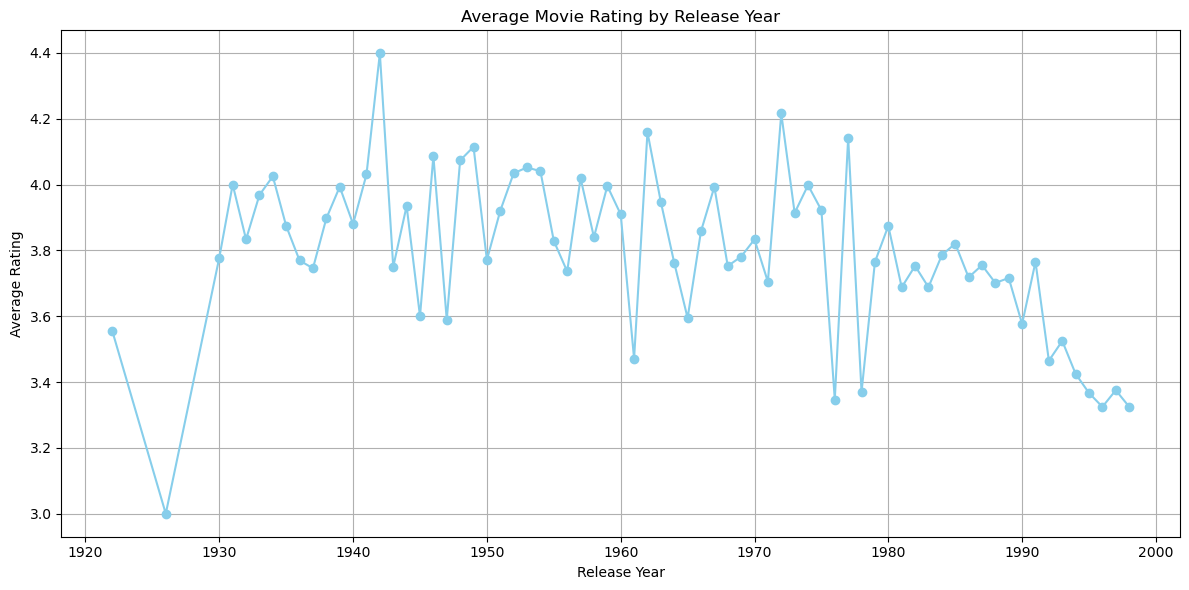

In [16]:
# Ensure release_date is parsed properly
rating_df['release_date'] = pd.to_datetime(rating_df['release_date'], errors='coerce')

# Extract release year
rating_df['release_year'] = rating_df['release_date'].dt.year

# Group by release year and compute average rating
avg_rating_by_year = rating_df.groupby('release_year')['rating'].mean()

# Drop NaNs (in case some movies had missing or malformed dates)
avg_rating_by_year = avg_rating_by_year.dropna()

# Plotting
plt.figure(figsize=(12, 6))
avg_rating_by_year.plot(kind='line', marker='o', color='skyblue')
plt.title('Average Movie Rating by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

From the figure it can be inferred that newer movies have been criticised more than older ones

Next we find the rating trend for each genre by release year. To do this we learn a linear regression model.

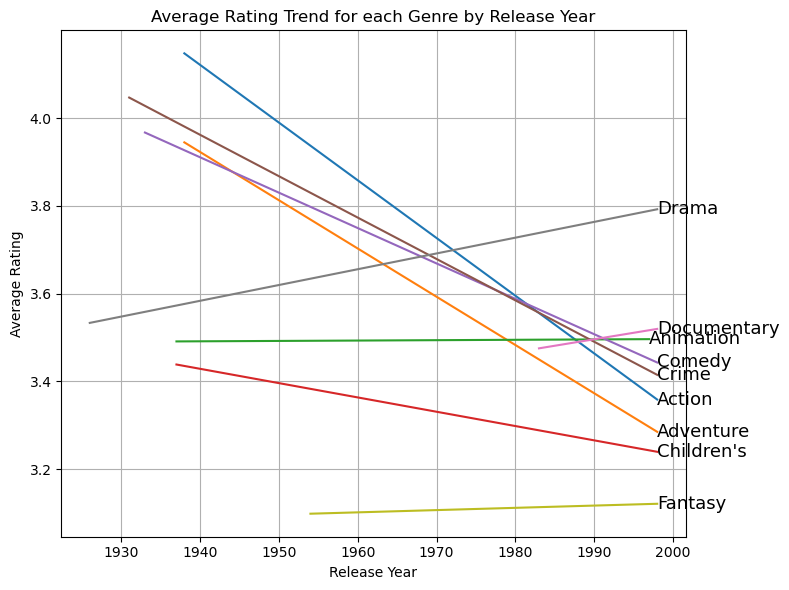

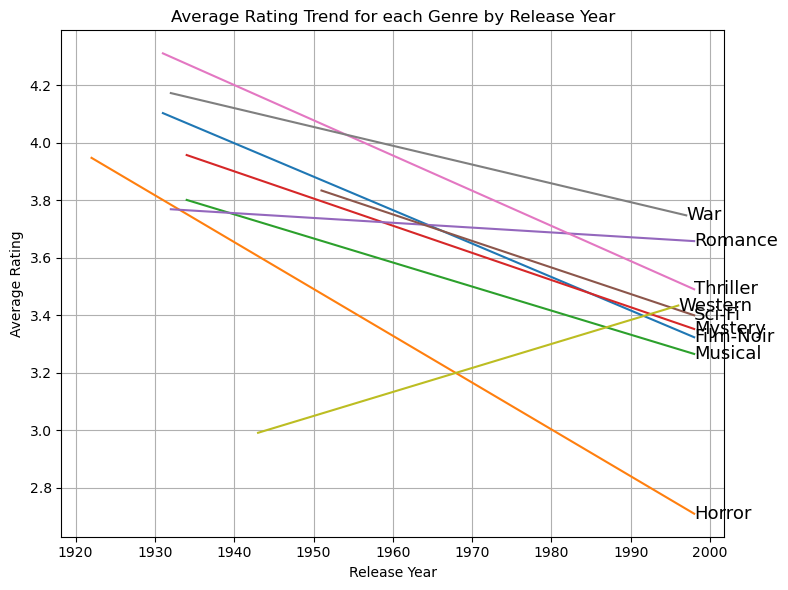

In [68]:
def plot_regression_genre_year(genres):
    genre_yearly_avg = {}

    # Calculate average ratings per release year for each genre
    for genre in genres:
        # Filter only movies of that genre
        genre_df = rating_df[rating_df[genre] == 1]

        # Group by release year and compute mean rating
        yearly_avg = genre_df.groupby('release_year')['rating'].mean()

        genre_yearly_avg[genre] = yearly_avg

    # Combine into a DataFrame
    genre_avg_df = pd.DataFrame(genre_yearly_avg)


    plt.figure(figsize=(8, 6))

    for genre in genres:
        # Drop NaNs
        genre_data = genre_avg_df[genre].dropna()
        years = genre_data.index.values.reshape(-1, 1)
        ratings = genre_data.values.reshape(-1, 1)

        # Fit linear regression
        model = LinearRegression()
        model.fit(years, ratings)
        trend = model.predict(years)


        # Plot regression line
        plt.plot(years.flatten(), trend.flatten(), label=f'{genre} Trend')
        plt.text(years[-1], trend[-1], genre, fontsize=13,
                 verticalalignment='center', horizontalalignment='left')

    plt.title('Average Rating Trend for each Genre by Release Year')
    plt.xlabel('Release Year')
    plt.ylabel('Average Rating')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


half_n = len(genre_cols) // 2
selected_genres = genre_cols[:half_n]

plot_regression_genre_year(selected_genres)

selected_genres = genre_cols[half_n:]
plot_regression_genre_year(selected_genres)

From the plots it can be inferred that the rating trend for Western, Documentary and Drama movies has been improving over the years while all other genres have been met with more criticism over the years.

# Recommender Systems using Matrix Factorization Implementation

In [38]:
#Implementation inspired from https://medium.com/data-science/recommendation-system-matrix-factorization-d61978660b4b
def matrix_factorization(R, k, alpha, beta):
    """
    R: User-Item rating matrix (numpy array)
    k: Number of latent features
    steps: Number of SGD iterations
    alpha: Learning rate
    beta: Regularization parameter
    """
    num_users, num_items = R.shape

    # Randomly initialize user and item latent factor matrices
    P = np.random.rand(num_users, k)
    Q = np.random.rand(num_items, k)

    # Get list of known rating indices (non-zero)
    rows, cols = R.nonzero()
    ratings = list(zip(rows, cols))

    for step in range(100):
        for i, j in ratings:
            eij = R[i, j] - np.dot(P[i, :], Q[j, :])
            P[i, :] += alpha * (eij * Q[j, :] - beta * P[i, :])
            Q[j, :] += alpha * (eij * P[i, :] - beta * Q[j, :])

    return P, Q

def calculate_rmse(P, Q, R):

    R_pred = P @ Q.T
    # Calculate RMSE of only non-zero values in R
    mask = R > 0
    rmse = np.sqrt(np.mean((R[mask] - R_pred[mask]) ** 2))
    return rmse


def create_rating_matrix(rating_matrix, num_users, num_items):

    R = np.zeros((num_users, num_items))
    for rating in rating_matrix:
        R[rating[0]-1, rating[1]-1] = rating[2]


    return R



def grid_search_CV(data, num_users, num_items, alphas, betas, ks):
    """
    Grid search for matrix factorization using half-validation split (no parallelization).

    Parameters:
    - data: Array of [user_id, item_id, rating]
    - num_users: Total number of users
    - num_items: Total number of items
    - alphas: List of learning rates
    - betas: List of regularization terms
    - ks: List of latent factor dimensions

    Returns:
    - Best (alpha, beta, k) combination based on validation RMSE
    """
    # Split data 50/50 into train and validation
    mid = len(data) // 2
    train_data = data[:mid]
    val_data = data[mid:]

    R_train = create_rating_matrix(train_data, num_users, num_items)
    R_val = create_rating_matrix(val_data, num_users, num_items)

    best_rmse = float('inf')
    best_params = None

    # Loop over all parameter combinations
    for alpha, beta, k in product(alphas, betas, ks):
        P, Q = matrix_factorization(R_train, k=k, alpha=alpha, beta=beta)
        val_rmse = calculate_rmse(P, Q, R_val)

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_params = (alpha, beta, k, P, Q)

    return best_params


def nested_cv(data, num_users, num_items, alphas, betas, ks, outer_splits):



    outer_kf = KFold(n_splits=outer_splits, shuffle=True)
    test_rmses = []

    for fold, (train_val_indices, test_indices) in enumerate(outer_kf.split(data)):

        train_val_data = data[train_val_indices]
        test_data = data[test_indices]

        R_test = create_rating_matrix(test_data, num_users, num_items)

        #Use train-val dataset to find optimal hyperparameters and matrices P, Q
        best_alpha, best_beta, best_k, P, Q = grid_search_CV(train_val_data, num_users, num_items, alphas, betas, ks)
        print(f"\nBest Params for fold {fold+1}: alpha={best_alpha}, beta={best_beta}, k={best_k}")



        test_rmse = calculate_rmse(P, Q, R_test)
        test_rmses.append(test_rmse)
        print(f"RMSE for fold {fold+1}:{test_rmse}")


    print(f"Average RMSE:{np.mean(test_rmses)}")


In [45]:
#Prepare data
ratings_df = pd.read_csv('ml-100k/ml-100k/u.data', sep='\t',  header=None, names=['user-id', 'item-id', 'rating', 'timestamp'], encoding='latin-1', engine='python')

ratings_df = ratings_df.drop(columns=['timestamp'])


ratings_data = ratings_df.to_numpy()

num_users = users_df.shape[0]
num_items = movies_df.shape[0]

alphas = [1e-2, 1e-4]
betas = [1e-1, 1e-4]
ks = [10,20,30,40,50]

nested_cv(ratings_data, num_users,num_items, alphas,betas, ks, outer_splits=3)


Best Params for fold 1: alpha=0.01, beta=0.1, k=20
RMSE for fold 1:1.0987258354778278

Best Params for fold 2: alpha=0.01, beta=0.1, k=20
RMSE for fold 2:1.0718939140482417

Best Params for fold 3: alpha=0.01, beta=0.1, k=20
RMSE for fold 3:1.073986144950478
Average RMSE:1.081535298158849


# Recommender Systems Using Matrix Factorization Libraries


We choose the off-the shelf NMF Implementation from sklearn.decomposition to perform matrix factorization. NMF can only work on non-negative matrices which suits our problem since the rating matrix is strictly non-negative. In addition, the NMF Implementation is also highly efficient and fast.

In [61]:
def calculate_rmse_nmf(true_R, pred_R):
    mask = true_R > 0
    return np.sqrt(mean_squared_error(true_R[mask], pred_R[mask]))

def nmf_grid_search_cv(ratings, num_users, num_items, latent_dims, betas):

    kf = KFold(n_splits=3, shuffle=True)
    best_rmse = float('inf')
    best_params = None

    for n_components in latent_dims:
        for beta in betas:

            val_rmses = []
            for train_idx, val_idx in kf.split(ratings):
                train_data = ratings[train_idx]
                val_data = ratings[val_idx]

                R_train = create_rating_matrix(train_data, num_users, num_items)
                R_val = create_rating_matrix(val_data, num_users, num_items)

                # Fit NMF with coordinate descent
                model = NMF(n_components=n_components, init='nndsvd', max_iter=2000,
                            solver='cd', alpha_W=beta, alpha_H=beta, l1_ratio=0.1)
                W = model.fit_transform(R_train)
                H = model.components_


                R_pred = np.dot(W, H)

                val_rmse = calculate_rmse_nmf(R_val, R_pred)
                val_rmses.append(val_rmse)

            avg_rmse = np.mean(val_rmses)
            print(f"Latent dimension: {n_components}, Beta: {beta}, RMSE: {avg_rmse:.4f}")

            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                best_params = (n_components, beta)

    print(f"\nBest Params: Latent Dimension:{best_params[0]}, Beta:{best_params[1]}, RMSE={best_rmse:.4f}")



In [62]:

latent_dims = [10,15,20,30]
betas = [1e-4, 1e-7, 1e-10]



nmf_grid_search_cv(ratings_data, num_users, num_items, latent_dims, betas)

Latent dimension: 10, Beta: 0.0001, RMSE: 2.8022
Latent dimension: 10, Beta: 1e-07, RMSE: 2.8007
Latent dimension: 10, Beta: 1e-10, RMSE: 2.8019
Latent dimension: 15, Beta: 0.0001, RMSE: 2.7997
Latent dimension: 15, Beta: 1e-07, RMSE: 2.7943
Latent dimension: 15, Beta: 1e-10, RMSE: 2.7973
Latent dimension: 20, Beta: 0.0001, RMSE: 2.8181
Latent dimension: 20, Beta: 1e-07, RMSE: 2.8124
Latent dimension: 20, Beta: 1e-10, RMSE: 2.8144
Latent dimension: 30, Beta: 0.0001, RMSE: 2.8566
Latent dimension: 30, Beta: 1e-07, RMSE: 2.8590
Latent dimension: 30, Beta: 1e-10, RMSE: 2.8661

Best Params: Latent Dimension:15, Beta:1e-07, RMSE=2.7943


Compared to the previous matrix factorization implementation, NMF yields significantly higher RMSE values. This performance gap can largely be attributed to the extreme sparsity of the rating matrix derived from the 100k dataset. In the rating matrix, 0 indicates unknown values. However, NMF treats these 0 entries as actual ratings representing dislike. As a result, the model attempts to learn both observed ratings and artificial zeros, introducing a bias into the optimization process. This misrepresentation skews the learned latent factors and leads to poor generalization performance on unseen data.